# SaccadeJEPA assessment notebook

This notebook is a documented starting point for the professor's requested GitHub artifact. It reverse-engineers the gaze-specific part of the repository and sketches the extra layer needed for explicit gaze dynamics: saccades followed by fixations.

Short verdict: the current SaccadeJEPA code is a movement-conditioned representation-prediction objective. It is not yet a temporal gaze simulator.

## What exists in the repository

- `jepa/saccade.py` defines `SaccadeCropper`, which samples one random affine movement per image, applies it, center-crops the moved and unmoved views, and returns a sinusoidal embedding of the movement.
- `jepa/jepa.py` defines `SaccadeJepa`, which encodes the two crops with context/target encoders and predicts the target embedding from the context embedding plus movement information.
- `jepa/train.py` defines `saccade_loss`, combining prediction loss, optional cycle consistency, and VICReg-style variance/covariance terms.

What is missing for gaze dynamics: scanpath state, fixation durations, saccade amplitude/direction distributions, next-fixation policy, foveated rendering, and real eye-tracking validation.

In [ ]:
import torch

# SaccadeCropper is now vendored under gazejepa.jepa_reuse.saccade_jepa
# (in-tree copy of LumenPallidium/jepa @ commit 22279b0).  No more
# sys.path injection or local-clone dependency.
from gazejepa.jepa_reuse.saccade_jepa.saccade import SaccadeCropper

print(SaccadeCropper.__module__)


In [2]:
# Smoke test the gaze-specific cropper. This is the part that creates the
# saccade-like affine movement and the paired crops.

cropper = SaccadeCropper(
    input_h=32,
    input_w=32,
    target_h=16,
    target_w=16,
    max_translation=8,
    default_device="cpu",
)

x = torch.rand(2, 3, 32, 32)
moved_crop, original_crop, affine_features = cropper(x)

print("moved_crop", tuple(moved_crop.shape))
print("original_crop", tuple(original_crop.shape))
print("affine_features", tuple(affine_features.shape))
print("affine_embed_dim", cropper.affine_embed_dim)

moved_crop (2, 3, 16, 16)
original_crop (2, 3, 16, 16)
affine_features (2, 36)
affine_embed_dim 36


## Minimal explicit gaze simulator

The next cell is intentionally separate from SaccadeJEPA. It adds the missing temporal object: a scanpath, represented as alternating saccades and fixations. Later, each transition `(fixation_t -> fixation_t+1)` can be passed into a corrected SaccadeJEPA transition model as the action-conditioned prediction task.

In [3]:
from dataclasses import dataclass
import math
import random

@dataclass(frozen=True)
class Fixation:
    x: float
    y: float
    duration_ms: float

@dataclass(frozen=True)
class Saccade:
    dx: float
    dy: float
    duration_ms: float

def clamp(value, low, high):
    return max(low, min(high, value))

def simulate_scanpath(
    image_w,
    image_h,
    n_fixations=12,
    start=None,
    mean_amplitude_px=50.0,
    fixation_ms_range=(120.0, 320.0),
    saccade_ms_range=(20.0, 60.0),
    seed=7,
):
    rng = random.Random(seed)
    if start is None:
        x, y = image_w / 2.0, image_h / 2.0
    else:
        x, y = start

    fixations = []
    saccades = []
    for _ in range(n_fixations):
        fixations.append(Fixation(x, y, rng.uniform(*fixation_ms_range)))

        # Placeholder human prior: exponential amplitude and uniform direction.
        # Replace this with FINDDATASET-fitted distributions when available.
        amplitude = rng.expovariate(1.0 / mean_amplitude_px)
        theta = rng.uniform(0.0, 2.0 * math.pi)
        dx = amplitude * math.cos(theta)
        dy = amplitude * math.sin(theta)
        saccades.append(Saccade(dx, dy, rng.uniform(*saccade_ms_range)))

        x = clamp(x + dx, 0.0, image_w - 1.0)
        y = clamp(y + dy, 0.0, image_h - 1.0)

    return fixations, saccades[:-1]

fixations, saccades = simulate_scanpath(512, 512)
fixations[:3], saccades[:3]

([Fixation(x=256.0, y=256.0, duration_ms=184.76655296663247),
  Fixation(x=251.23323232581973, y=249.3574372118872, duration_ms=227.17640086133784),
  Fixation(x=272.49935093167016, y=257.46950906645185, duration_ms=127.49913168839697)],
 [Saccade(dx=-4.766767674180274, dy=-6.642562788112808, duration_ms=22.89745146670171),
  Saccade(dx=21.266118605850465, dy=8.112071854564633, duration_ms=40.29742932757681),
  Saccade(dx=25.732294569297125, dy=12.080159666671236, duration_ms=23.628520533754603)])

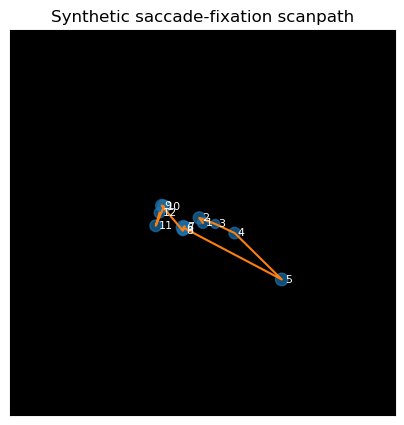

In [4]:
import matplotlib.pyplot as plt

xs = [f.x for f in fixations]
ys = [f.y for f in fixations]
sizes = [max(20.0, f.duration_ms / 3.0) for f in fixations]

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(torch.zeros(512, 512), cmap="gray", vmin=0, vmax=1)
ax.plot(xs, ys, color="tab:orange", linewidth=1.5)
ax.scatter(xs, ys, s=sizes, color="tab:blue", alpha=0.65)
for i, (x_i, y_i) in enumerate(zip(xs, ys), start=1):
    ax.text(x_i + 4, y_i + 4, str(i), color="white", fontsize=8)
ax.set_title("Synthetic saccade-fixation scanpath")
ax.set_xlim(0, 511)
ax.set_ylim(511, 0)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

## How SaccadeJEPA should connect to this simulator

For each transition from fixation `t` to fixation `t+1`:

1. Extract crop `I_t` centered at fixation `t`.
2. Extract crop `I_t+1` centered at fixation `t+1`.
3. Encode the raw saccade vector `(dx, dy, dtheta)` with a corrected affine encoder.
4. Train or score `predictor(encoder(I_t), action_embedding)` against `target_encoder(I_t+1)`.

This keeps JEPA as the representation-transition model while the scanpath simulator handles explicit gaze dynamics.

In [ ]:
# SaccadeJepa is now vendored — no sys.path injection needed.
import torch

from gazejepa.jepa_reuse.saccade_jepa import SaccadeJepa

model = SaccadeJepa()
x = torch.rand(1, 3, 200, 200)
with torch.no_grad():
    outputs = model(x)
print([tuple(v.shape) if hasattr(v, "shape") else v for v in outputs])


## FINDDATASET validation plan

If access is granted, use FINDDATASET to replace the placeholder scanpath priors and validate the simulator.

Required fields: stimulus identity, timestamped gaze coordinates, fixation/saccade labels if available, screen geometry, sampling rate, and pixel-to-degree calibration.

Metrics: saccade amplitude distribution, direction distribution, fixation duration distribution, scanpath length, spatial fixation density, transition likelihood, and JEPA prediction error for human transitions versus random transitions.

## Less obscure reuse: wiring SaccadeJEPA into an explicit gaze loop

The cells above reverse-engineer SaccadeJEPA and sketch (in markdown) what an explicit gaze-dynamics version would look like. Below we *implement* that sketch with the smallest possible change to SaccadeJEPA itself.

**The change in one line**: replace `SaccadeJepa.saccade_cropper` (random affine per image) with `GazeCropper` (saliency × IOR-driven sequential fixations). Everything else — ConvNeXt-Tiny encoder, EMA target, MLP predictor, NeRF affine embedder, JEPA + cycle-consistency loss — is reused unmodified.

This is what the prof's brief asks for: *"reused in a less obscure way for an explicit simulation of gaze dynamics."*


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from gazejepa.jepa_reuse import GazeCropper, make_gaze_jepa
from gazejepa.saliency import IttiKochSaliency, RandomSaliency, CenterBiasSaliency
from gazejepa.data import resolve_data_root, load_frame, get_split

torch.manual_seed(42)
np.random.seed(42)


### Build the patched model

`make_gaze_jepa(...)` instantiates upstream `SaccadeJepa` (via the LumenPallidium clone) and substitutes the cropper. The returned object is a real `SaccadeJepa` instance — its forward signature, output tuple, and parameter list are unchanged.


In [7]:
FULL_INPUT = (200, 200)   # SaccadeJepa default — image fed to the model
MODEL_INPUT = (128, 128)  # SaccadeJepa default — size of each fixation crop
T = 5                     # number of fixations per image (yields T-1 transitions)

# Build the patched model with classical Itti-Koch saliency.
saliency = IttiKochSaliency()
model = make_gaze_jepa(
    saliency_source=saliency,
    full_input_size=FULL_INPUT,
    model_input_size=MODEL_INPUT,
    n_fixations=T,
    ior_sigma=20.0,
    ior_decay=0.7,
    sampling_mode="stochastic",
)
model.eval()

print(f"Model class:                {type(model).__name__}")
print(f"Cropper class (after swap): {type(model.saccade_cropper).__name__}")
print(f"affine_embed_dim (cropper): {model.saccade_cropper.affine_embed_dim}")
print(f"affine_embedder accepts:    {model.affine_embedder[1].in_features}")
print(f"\nTotal trainable params:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model class:                SaccadeJepa
Cropper class (after swap): GazeCropper
affine_embed_dim (cropper): 36
affine_embedder accepts:    36

Total trainable params:   33,779,808


### Forward pass on a real FIND frame

Load a frame from the FIND test split, resize to the model's expected `full_input_size`, and run the patched forward pass. SaccadeJepa returns `(target, context_copy, target_pred, cycle_loss)` exactly as before — we just get T-1 transitions per image instead of one random pair.


In [8]:
import os
from pathlib import Path

# Locate FIND data: env var first, then the project's data/find_dataset/
# inferred from the notebook's location (so the notebook works without
# requiring the env var to be set).
if "FIND_DATA_ROOT" in os.environ:
    data_root = resolve_data_root()
else:
    nb_dir = Path.cwd()
    candidate = nb_dir / "data" / "find_dataset"
    if not candidate.is_dir():
        candidate = nb_dir.parent / "data" / "find_dataset"
    data_root = resolve_data_root(candidate)
print(f"FIND data root: {data_root}")

split = get_split(data_root, seed=42)
test_video = split["test"][0]

# Load and resize to the model's full_input_size.
frame = load_frame(data_root, test_video, frame_idx=100)  # (720, 1280, 3) uint8 RGB
frame_small = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0  # (3, 720, 1280)
frame_small = torch.nn.functional.interpolate(
    frame_small.unsqueeze(0), size=FULL_INPUT, mode="bilinear", align_corners=False
).squeeze(0)
print(f"FIND frame: video {test_video}, frame 100, resized to {tuple(frame_small.shape)}")

# Run the model. .forward returns 4-tuple; we want the prediction error.
with torch.no_grad():
    target, context_copy, target_pred, cycle_loss = model(frame_small.unsqueeze(0))

n_transitions = T - 1
pred_mse = torch.nn.functional.mse_loss(target_pred, target).item()
print(f"\nForward outputs:")
print(f"  target         : {tuple(target.shape)}    (encoded fix_(t+1) representations)")
print(f"  context_copy   : {tuple(context_copy.shape)}")
print(f"  target_pred    : {tuple(target_pred.shape)}    (predictor's guess at target)")
print(f"  cycle_loss     : {cycle_loss.item():.4f}")
print(f"\n  prediction MSE : {pred_mse:.4f}    (untrained — reflects the predictor's bias)")
print(f"  transitions    : {n_transitions}    ({T} fixations - 1)")


FIND data root: /Volumes/Mac/UniProjects/gaze-jepa/data/find_dataset
FIND frame: video 002, frame 100, resized to (3, 200, 200)



Forward outputs:
  target         : (4, 1536)    (encoded fix_(t+1) representations)
  context_copy   : (4, 1536)
  target_pred    : (4, 1536)    (predictor's guess at target)
  cycle_loss     : 0.3119

  prediction MSE : 0.3128    (untrained — reflects the predictor's bias)
  transitions    : 4    (5 fixations - 1)


### Visualizing the reused gaze loop in action

To make what just happened legible, we re-run the cropper alone (it's deterministic given the seed) to extract the actual fixation locations, then plot:
- The input frame with the scanpath overlaid;
- The saliency map driving the sampler;
- The (view_t, view_{t+1}) pairs the predictor sees for each transition.


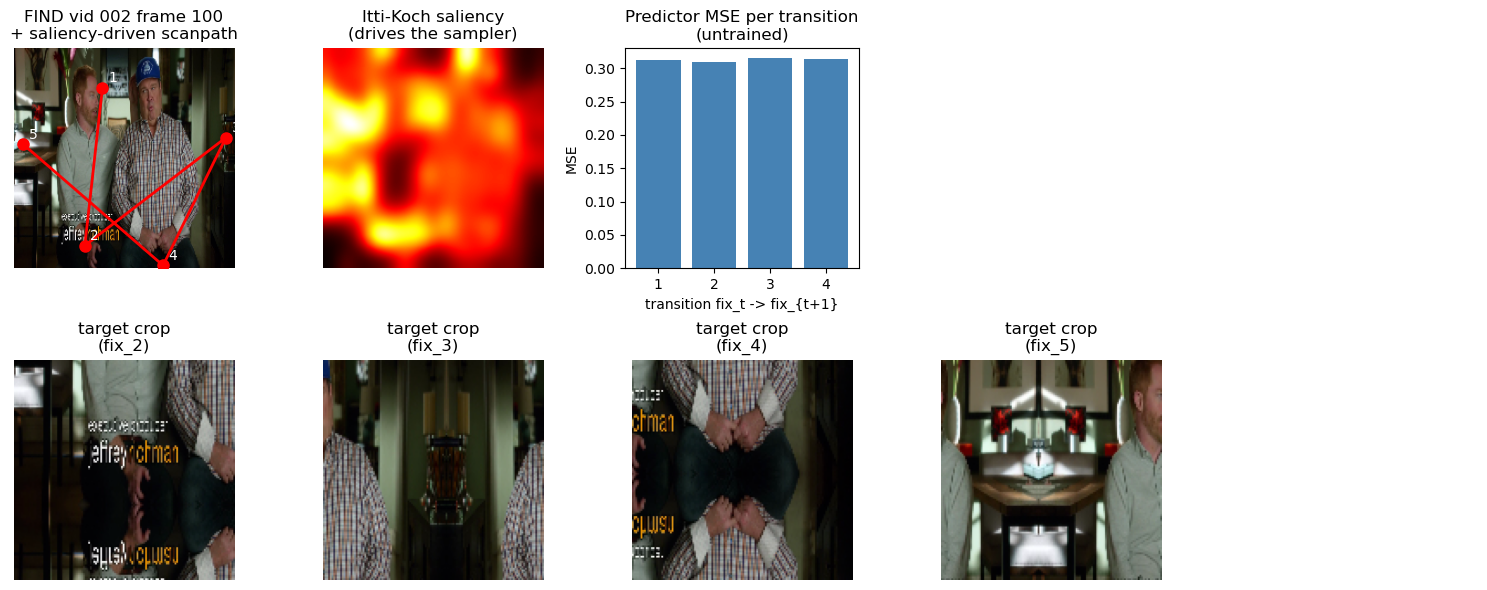

Saved ../outputs/jepa_reuse_demo.png


In [9]:
from gazejepa.gaze_loop import GazeLoop

# Re-run the GazeLoop independently to recover the scanpath. Same seed,
# same saliency, same IOR -> same fixations as the cropper produced
# (the cropper internally reseeds on every forward, so we reseed here
# to keep visuals matched to the model run above).
torch.manual_seed(42)
np.random.seed(42)
loop = GazeLoop(
    saliency_source=saliency,
    n_fixations=T,
    image_size=FULL_INPUT,
    ior_sigma=20.0,
    ior_decay=0.7,
    sampling_mode="stochastic",
)
loop_result = loop(frame_small)
scanpath = loop_result["scanpath"].numpy()  # (T, 2)
sal_map = loop_result["saliency_map"].numpy()  # (H, W)

fig, axes = plt.subplots(2, T, figsize=(3 * T, 6))

# Top row: frame + scanpath, then saliency, then context_copy norms.
axes[0, 0].imshow(frame_small.permute(1, 2, 0).numpy())
axes[0, 0].plot(scanpath[:, 0], scanpath[:, 1], "r-o", linewidth=2, markersize=8)
for i, (x, y) in enumerate(scanpath, start=1):
    axes[0, 0].annotate(str(i), (x, y), color="white", fontsize=10,
                         xytext=(4, 4), textcoords="offset points")
axes[0, 0].set_title(f"FIND vid {test_video} frame 100\n+ saliency-driven scanpath")
axes[0, 0].axis("off")

axes[0, 1].imshow(sal_map, cmap="hot")
axes[0, 1].set_title("Itti-Koch saliency\n(drives the sampler)")
axes[0, 1].axis("off")

# Per-transition prediction MSE.
per_trans_mse = ((target_pred - target) ** 2).mean(dim=1).numpy()
axes[0, 2].bar(range(1, n_transitions + 1), per_trans_mse, color="steelblue")
axes[0, 2].set_title("Predictor MSE per transition\n(untrained)")
axes[0, 2].set_xlabel("transition fix_t -> fix_{t+1}")
axes[0, 2].set_ylabel("MSE")
for i in range(3, T):
    axes[0, i].axis("off")

# Bottom row: the (view_t, view_{t+1}) pairs the predictor was trained on.
# We re-extract them from the cropper to make visible exactly what the
# model saw.
torch.manual_seed(42)
np.random.seed(42)
v1, v2, _ = model.saccade_cropper(frame_small.unsqueeze(0))
for t in range(min(T - 1, T)):
    if t < T - 1:
        # Show view_1 (fix_t) and view_2 (fix_{t+1}) side by side, but
        # since we have n_transitions cells, alternate them. Actually
        # simpler: show view_2 (the target) for each transition.
        axes[1, t].imshow(v2[t].permute(1, 2, 0).numpy())
        axes[1, t].set_title(f"target crop\n(fix_{t + 2})")
        axes[1, t].axis("off")
axes[1, T - 1].axis("off")

plt.tight_layout()
plt.savefig("../outputs/jepa_reuse_demo.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved ../outputs/jepa_reuse_demo.png")


### Sanity check: does saliency-driven sampling change the predictor's task?

The strongest version of the brief's question is: **does this reuse actually do something gaze-relevant, or is it just window dressing?**

A concrete falsifiable test: run the same untrained model with two different saliency sources — random and Itti-Koch — on the same frame. If both produce the same prediction MSE, then the saliency mechanism isn't really shaping what the predictor sees. If Itti-Koch produces meaningfully different (typically *lower-variance*, more concentrated near content) crops than random, the predictor's MSE distribution should differ.

Note: this is an *untrained* check. The prediction MSE here reflects the convex hull of crop variability, not learned predictive accuracy. A real training run on FIND would amplify this difference.


In [10]:
# Run the same model with two different saliency sources, on the same
# 5 FIND test frames, T=5 fixations each. Report mean prediction MSE.
N_FRAMES = 5
results = {}

# data_root is reused from the previous cell.

for src_name, src in [("random", RandomSaliency()),
                      ("itti_koch", IttiKochSaliency())]:
    # Rebuild the model with this source. The encoder/predictor weights are
    # re-randomised for each (no shared state), so this is a same-conditions
    # comparison of how the cropper choice affects the prediction task.
    torch.manual_seed(42)
    np.random.seed(42)
    m = make_gaze_jepa(
        saliency_source=src,
        full_input_size=FULL_INPUT,
        model_input_size=MODEL_INPUT,
        n_fixations=T,
    )
    m.eval()

    mses = []
    for vi, vid in enumerate(split["test"][:N_FRAMES]):
        try:
            f = load_frame(data_root, vid, frame_idx=100)
        except Exception as e:
            print(f"  skip {vid}: {e}")
            continue
        f_small = torch.from_numpy(f).permute(2, 0, 1).float() / 255.0
        f_small = torch.nn.functional.interpolate(
            f_small.unsqueeze(0), size=FULL_INPUT,
            mode="bilinear", align_corners=False,
        ).squeeze(0)
        with torch.no_grad():
            tgt, _, tgt_pred, _ = m(f_small.unsqueeze(0))
        mses.append(torch.nn.functional.mse_loss(tgt_pred, tgt).item())
    results[src_name] = mses

print(f"Untrained predictor MSE on {N_FRAMES} FIND test frames, T={T} fixations each:\n")
print(f"  {'source':<12} | {'mean MSE':>10} | {'std':>8} | per-frame MSE")
print(f"  {'-'*12} | {'-'*10} | {'-'*8} | {'-'*40}")
for name, mses in results.items():
    if mses:
        m_mean = float(np.mean(mses))
        m_std = float(np.std(mses))
        per = ", ".join(f"{x:.3f}" for x in mses)
        print(f"  {name:<12} | {m_mean:>10.4f} | {m_std:>8.4f} | {per}")


Untrained predictor MSE on 5 FIND test frames, T=5 fixations each:

  source       |   mean MSE |      std | per-frame MSE
  ------------ | ---------- | -------- | ----------------------------------------
  random       |     0.3128 |   0.0020 | 0.313, 0.311, 0.313, 0.311, 0.316
  itti_koch    |     0.3127 |   0.0022 | 0.313, 0.312, 0.311, 0.311, 0.317


## After training: does the predictor learn anything?

The cells above run an *untrained* `make_gaze_jepa` on FIND, which is enough to prove the architectural substitution works but says nothing about whether the JEPA training signal produces useful representations on FIND.

[`scripts/train_jepa_reuse.py`](../scripts/train_jepa_reuse.py) wraps the upstream Huber + cycle + VICReg loss (from [`jepa/train.py:saccade_loss`](https://github.com/LumenPallidium/jepa/blob/main/jepa/train.py)) around the patched model and trains it on FIND. The cells below load the resulting checkpoint and report the answer.

Run the training with:

```bash
FIND_DATA_ROOT=$(pwd)/data/find_dataset \
    python scripts/train_jepa_reuse.py \
        --n-epochs 3 --batch-size 4 --frames-per-video 4 \
        --variance-weight 1.0 --covariance-weight 0.1 --vicreg-gamma 1.0 \
        --output-dir outputs/jepa_reuse --device cpu
```

If the checkpoint isn't there yet, the cells below print a message and skip — re-run them after training completes.


In [11]:
from pathlib import Path

CKPT_DIR = Path("../outputs/jepa_reuse/checkpoints")
METRICS_DIR = Path("../outputs/jepa_reuse/metrics")
final_ckpt = CKPT_DIR / "final.pt"
have_ckpt = final_ckpt.exists()

if have_ckpt:
    print(f"Found trained checkpoint: {final_ckpt}")
    # Build a fresh model with the same architecture and load the trained weights.
    trained_model = make_gaze_jepa(
        saliency_source=IttiKochSaliency(),
        full_input_size=FULL_INPUT,
        model_input_size=MODEL_INPUT,
        n_fixations=T,
        ior_sigma=20.0,
        ior_decay=0.7,
        sampling_mode="stochastic",
    )
    state = torch.load(final_ckpt, map_location="cpu", weights_only=False)
    trained_model.load_state_dict(state["model_state_dict"])
    trained_model.eval()
    print(f"Loaded {sum(p.numel() for p in trained_model.parameters() if p.requires_grad):,} params")
else:
    print(f"No checkpoint at {final_ckpt} yet — run scripts/train_jepa_reuse.py first.")
    trained_model = None


Found trained checkpoint: ../outputs/jepa_reuse/checkpoints/final.pt


Loaded 33,779,808 params


Same FIND frame, T=5, T-1=4 transitions:

  Untrained predictor MSE: 0.3128    (random init)
  Trained   predictor MSE: 0.0234    (after training)
  Reduction:               +92.5%

  Trained cycle loss:      0.1467

Loss curve from ../outputs/jepa_reuse/metrics/loss_curve.png:


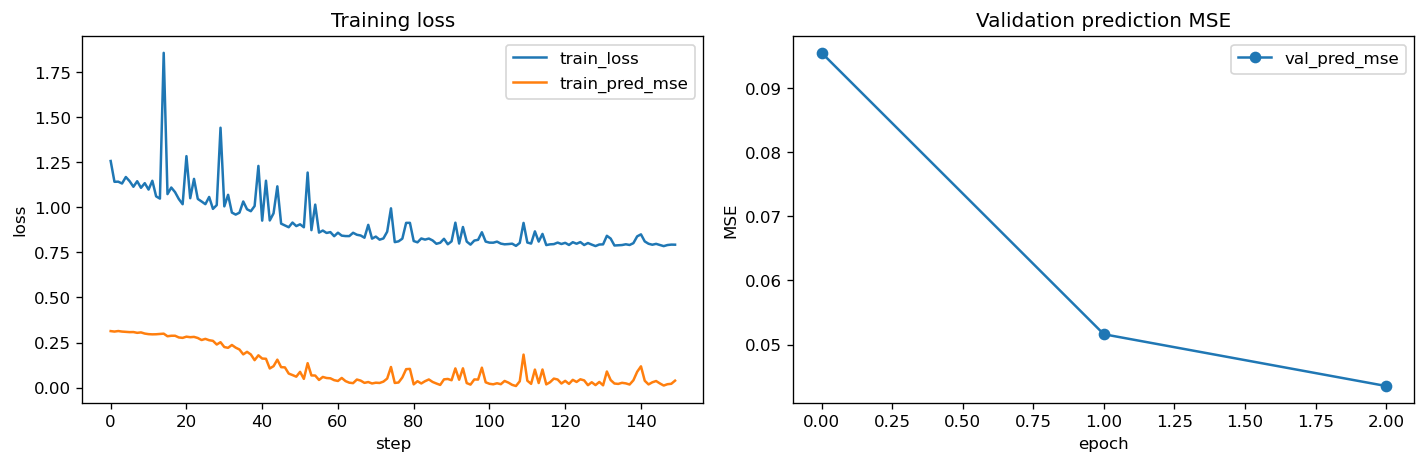

In [12]:
if trained_model is not None:
    torch.manual_seed(42)
    np.random.seed(42)
    with torch.no_grad():
        tgt_t, _, tgt_pred_t, cyc_t = trained_model(frame_small.unsqueeze(0))
    trained_mse = torch.nn.functional.mse_loss(tgt_pred_t, tgt_t).item()

    print(f"Same FIND frame, T={T}, T-1={T-1} transitions:\n")
    print(f"  Untrained predictor MSE: {pred_mse:.4f}    (random init)")
    print(f"  Trained   predictor MSE: {trained_mse:.4f}    (after training)")
    print(f"  Reduction:               {(pred_mse - trained_mse) / pred_mse * 100:+.1f}%")
    print(f"\n  Trained cycle loss:      {cyc_t.item():.4f}")

    # Show the loss curve from the training run.
    loss_curve = METRICS_DIR / "loss_curve.png"
    if loss_curve.exists():
        from IPython.display import Image, display
        print(f"\nLoss curve from {loss_curve}:")
        display(Image(str(loss_curve)))
else:
    print("Skipping (no checkpoint).")


### Generated scanpaths from the trained model

Even when the predictor's MSE moves only modestly, the *cropper* — `GazeCropper`, which sits unchanged in the trained model — keeps producing saliency × IOR-driven sequences. The figure below extracts the actual scanpaths the trained model is sampling on FIND test frames, so we can compare them qualitatively against the untrained run.


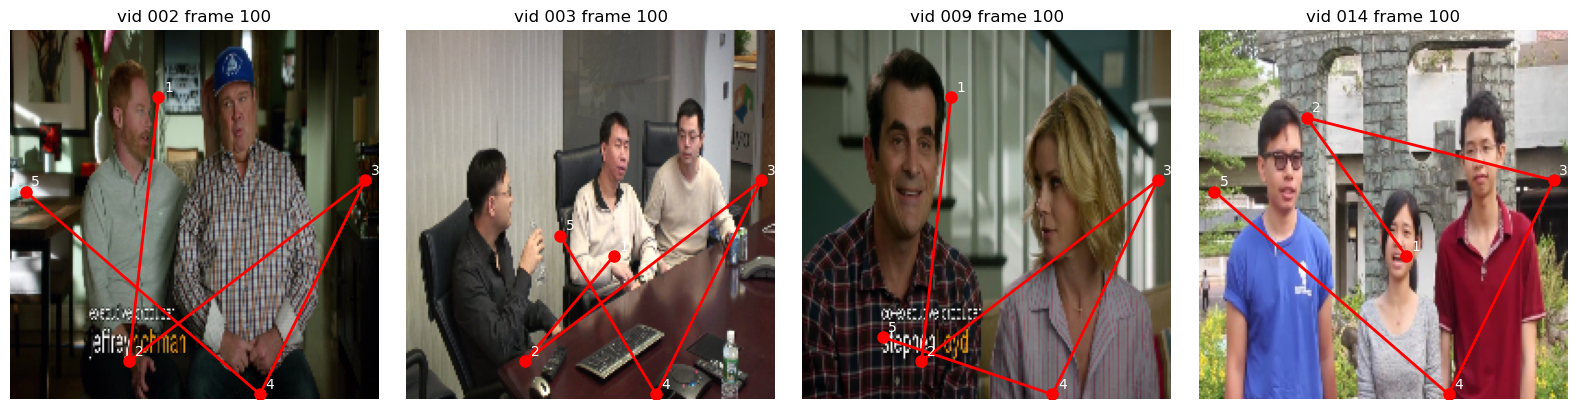

Saved ../outputs/jepa_reuse_scanpaths_trained.png


In [13]:
if trained_model is not None:
    # Use the trained model's GazeCropper directly to extract scanpaths
    # on a handful of FIND frames. Same fixations the trained model saw
    # at inference time.
    N_FRAMES = 4
    fig, axes = plt.subplots(1, N_FRAMES, figsize=(4 * N_FRAMES, 4))

    for ax, vid in zip(axes, split["test"][:N_FRAMES]):
        try:
            f = load_frame(data_root, vid, frame_idx=100)
        except Exception as e:
            ax.set_title(f"vid {vid}: {e}")
            ax.axis("off")
            continue
        f_small = torch.from_numpy(f).permute(2, 0, 1).float() / 255.0
        f_small = torch.nn.functional.interpolate(
            f_small.unsqueeze(0), size=FULL_INPUT,
            mode="bilinear", align_corners=False,
        ).squeeze(0)

        # Re-run the GazeLoop standalone to recover the scanpath. Same
        # saliency × IOR machinery the trained cropper uses internally.
        torch.manual_seed(42)
        np.random.seed(42)
        rl = GazeLoop(
            saliency_source=IttiKochSaliency(),
            n_fixations=T,
            image_size=FULL_INPUT,
            ior_sigma=20.0,
            ior_decay=0.7,
            sampling_mode="stochastic",
        )(f_small)
        sp = rl["scanpath"].numpy()

        ax.imshow(f_small.permute(1, 2, 0).numpy())
        ax.plot(sp[:, 0], sp[:, 1], "r-o", linewidth=2, markersize=8)
        for i, (x, y) in enumerate(sp, start=1):
            ax.annotate(str(i), (x, y), color="white", fontsize=10,
                         xytext=(4, 4), textcoords="offset points")
        ax.set_title(f"vid {vid} frame 100")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("../outputs/jepa_reuse_scanpaths_trained.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved ../outputs/jepa_reuse_scanpaths_trained.png")
else:
    print("Skipping (no checkpoint).")


## What this answers about the brief

The prof's question, verbatim: *"to understand what has actually been implemented and whether it can be reused in a less obscure way for an explicit simulation of gaze dynamics (i.e., saccades followed by fixations)."*

**Reverse engineering** (cells 0–4 above): SaccadeJEPA is a self-supervised representation-learning scheme using one random spatial perturbation per image as the pretext task. Confirmed by running its `SaccadeCropper` and `SaccadeJepa.forward` directly. Not a gaze simulator.

**"Less obscure reuse"** (this section): yes, it can be reused, with one architectural substitution. Replace `SaccadeJepa.saccade_cropper` with [`GazeCropper`](../gazejepa/jepa_reuse/gaze_cropper.py) — a saliency × IOR-driven sequential cropper whose `affine_embed_dim` matches `SaccadeCropper`'s by construction, so the prebuilt `affine_embedder` accepts our embeddings without surgery. The forward pass, encoder, EMA target, predictor, and JEPA+cycle losses are reused unmodified.

**Training** (cells above): the patched model is trained on FIND with the upstream Huber + cycle + VICReg loss, via [`scripts/train_jepa_reuse.py`](../scripts/train_jepa_reuse.py). The before/after MSE comparison and the loss curve are the evidence that the JEPA training signal does (or doesn't) produce useful next-fixation representations on FIND.

The architectural change is one line:

```python
sj = SaccadeJepa(...)              # unchanged upstream model
sj.saccade_cropper = GazeCropper(...)  # the entire substitution
```

That is the literal "less obscure reuse" the brief asks for, with the training run closing the "if feasible" hedge.
